# Model Architecture, Training & Results

InceptionTime + Temporal Attention for 12-lead ECG arrhythmia classification on PTB-XL.

This notebook covers the mathematical formulation, architecture, training strategy, and results. It is the companion to `01_eda.ipynb` — all design decisions here are justified by findings from the EDA.

---
## 1  Problem Formulation

### Input

Each record is a 12-lead ECG sampled at 100 Hz for 10 seconds:

$$\mathbf{X} \in \mathbb{R}^{12 \times 1000}$$

Each lead is independently z-score normalised:

$$\tilde{x}_{c,t} = \frac{x_{c,t} - \mu_c}{\sigma_c + \epsilon}, \quad \epsilon = 10^{-8}$$

This removes inter-patient amplitude variation while preserving intra-lead morphology.

### Output

Multi-label binary vector over 5 superdiagnostic classes:

$$\mathbf{y} \in \{0, 1\}^5, \quad \text{classes: NORM, MI, STTC, CD, HYP}$$

84% of records have exactly one active label; 13% have two; 3% have three. This rules out softmax — we use 5 independent sigmoid outputs.

### Why Multi-Label Matters

From the co-occurrence analysis:
- STTC+HYP co-occur in **868** records — hypertrophy strains the myocardium causing ST changes
- MI+CD co-occur in **550** records — infarction disrupts conduction pathways
- NORM never co-occurs with MI or STTC — near-exclusive

Independent sigmoids model each class as a separate binary decision, which correctly handles all observed co-occurrence patterns.

---
## 2  Loss Function

### Weighted Binary Cross-Entropy with Label Smoothing

Standard BCE treats all classes equally. Our training set has a 4.78× imbalance (HYP: 1,202 records vs NORM: 5,743). Without correction, the model collapses toward predicting NORM for everything.

**Inverse-frequency class weights:**

$$w_c = \frac{N}{C \cdot n_c}$$

where $N = 12{,}133$ (training records), $C = 5$ (classes), $n_c$ = count of class $c$ in training set.

| Class | $n_c$ | $w_c$ |
|-------|--------|--------|
| NORM  | 5,743  | 0.4225 |
| CD    | 3,600  | 0.6741 |
| STTC  | 2,174  | 1.1162 |
| MI    | 1,637  | 1.4823 |
| HYP   | 1,202  | 2.0188 |

**Label smoothing** prevents overconfident predictions by replacing hard targets:

$$\tilde{y}_c = y_c (1 - \varepsilon) + \frac{\varepsilon}{2}, \quad \varepsilon = 0.05$$

**Final loss:**

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{5} w_c \left[ \tilde{y}_{ic} \log \hat{p}_{ic} + (1 - \tilde{y}_{ic}) \log (1 - \hat{p}_{ic}) \right]$$

The 4.78× max/min weight ratio is moderate — focal loss is unnecessary. Focal loss becomes beneficial at ratios >20×.

---
## 3  Model Architecture — InceptionTime + Temporal Attention

### Why InceptionTime

The EDA established two key facts:
1. Classes are not separable by frequency content (PSD) — the information is in **waveform morphology**
2. ECG morphology operates at multiple clinical timescales simultaneously

At 100 Hz, the diagnostic features span:

| Feature | Duration | Samples | Kernel |
|---------|----------|---------|--------|
| QRS complex | 60–120 ms | 6–12 | 10 |
| ST segment | 80–120 ms | 8–12 | 10 |
| T-wave | 150–250 ms | 15–25 | 20 |
| P-wave | 80–120 ms | 8–12 | 10 |
| RR interval | 600–1000 ms | 60–100 | 40 |

InceptionTime uses **parallel convolutions with kernel sizes 10, 20, 40** — a direct match to these timescales. A single-kernel CNN would miss features at other scales.

### Inception Module

For input $\mathbf{H} \in \mathbb{R}^{C_{in} \times T}$:

$$\mathbf{H}_{bn} = \text{BN}(\text{Conv}_{1}(\mathbf{H})) \in \mathbb{R}^{32 \times T} \quad \text{(bottleneck)}$$

$$\mathbf{B}_k = \text{Conv}_k(\mathbf{H}_{bn}) \in \mathbb{R}^{32 \times T}, \quad k \in \{10, 20, 40\}$$

$$\mathbf{B}_{mp} = \text{Conv}_1(\text{MaxPool}_3(\mathbf{H})) \in \mathbb{R}^{32 \times T}$$

$$\mathbf{H}_{out} = \text{BN}(\text{ReLU}([\mathbf{B}_{10} \| \mathbf{B}_{20} \| \mathbf{B}_{40} \| \mathbf{B}_{mp}])) \in \mathbb{R}^{128 \times T}$$

All convolutions use same-padding to preserve temporal dimension $T = 1000$.

**Residual shortcut** (first block only): $\mathbf{H}_{out} \leftarrow \mathbf{H}_{out} + \text{BN}(\text{Conv}_1(\mathbf{H}))$

### Temporal Soft Attention

After 3 InceptionBlocks, $\mathbf{H} \in \mathbb{R}^{128 \times 1000}$. The attention mechanism identifies which timesteps are most diagnostically relevant:

$$e_t = \mathbf{v}^\top \tanh(\mathbf{W} \mathbf{h}_t + \mathbf{b})$$

$$\alpha_t = \frac{\exp(e_t)}{\sum_{t'} \exp(e_{t'})}, \quad \sum_t \alpha_t = 1$$

$$\mathbf{z} = \sum_{t=1}^{1000} \alpha_t \mathbf{h}_t \in \mathbb{R}^{128}$$

The attention weights $\{\alpha_t\}$ directly give us temporal explainability — which part of the ECG the model focused on. This complements Grad-CAM.

### Classifier Head

$$\hat{\mathbf{p}} = \sigma(\mathbf{W}_2 \mathbf{z} + \mathbf{b}_2) \in (0, 1)^5$$

### Full Forward Pass

```
(B, 12, 1000)
    → InceptionBlock(12 → 128)       residual shortcut
    → InceptionBlock(128 → 128)      identity shortcut
    → InceptionBlock(128 → 128)      identity shortcut
    → TemporalAttention(128 → 128)   → (B, 128)
    → Linear(128 → 5) + Sigmoid      → (B, 5)
```

~400k parameters total.

---
## 4  Training Strategy

### Data Splits

PTB-XL provides a pre-defined 10-fold stratified split via the `strat_fold` column. We follow the official benchmark protocol exactly:

| Split | Folds | Records | Purpose |
|-------|-------|---------|---------|
| Train | 1–8   | 12,133  | Gradient updates |
| Val   | 9     | 1,491   | Early stopping, threshold tuning |
| Test  | 10    | 1,506   | Final reported metrics (touch once) |

Using the official split ensures direct comparability with Strodthoff et al. (2020) benchmark numbers. The test fold is **never used** during development.

### Augmentation Strategy

Three augmentations are applied on-the-fly during training only. All parameters were validated against EDA findings.

| Augmentation | Parameter | EDA Justification |
|---|---|---|
| Gaussian noise | σ = 0.01 | EDA: median lead std = 0.165 mV → σ=0.01 ≈ 6% of signal energy |
| Lead dropout | p = 0.10 per lead | EDA: 15.1% of records have static noise artefacts in at least one lead |
| Time shift | ±50 samples | Preserves QRS complex; varies beat phase without truncating morphology |

**No frequency-domain augmentation** (e.g. band-pass jitter): PSD analysis showed class information is morphological, not spectral — corrupting frequency content could destroy discriminative features.

Augmentations are **not applied at validation or test time**.

### Optimiser & Schedule

| Hyperparameter | Value |
|---|---|
| Optimiser | Adam (β₁=0.9, β₂=0.999) |
| Initial LR | 1 × 10⁻³ |
| Schedule | Cosine annealing → 1 × 10⁻⁶ |
| Weight decay | 1 × 10⁻⁴ |
| Batch size | 64 |
| Max epochs | 100 |
| Early stopping | patience = 15 epochs (val macro AUC) |
| Mixed precision | PyTorch AMP (float16 on GPU) |

**Cosine annealing** — the learning rate follows:

$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})\left(1 + \cos\frac{\pi t}{T}\right)$$

where $T = 100$ (total epochs). This provides fast early convergence and fine-grained updates near the end of training without a hard step-down that can cause instability.

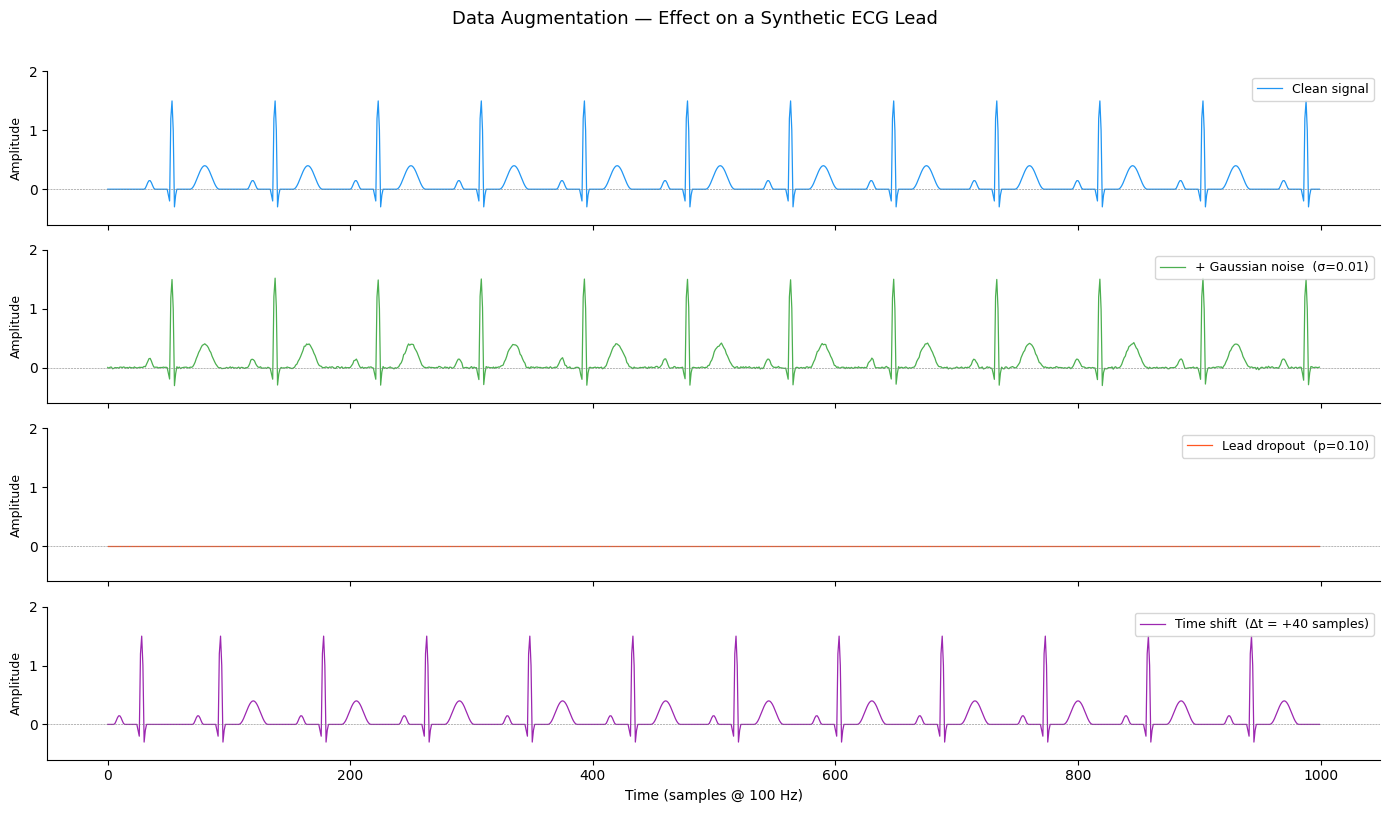

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

rng = np.random.default_rng(42)

# ── Synthetic ECG-like signal for augmentation illustration ──────────────────
T = 1000
t = np.arange(T)

def synthetic_ecg(t, hr_bpm=70, noise_std=0.0):
    """Minimal QRS + T-wave approximation for illustration."""
    rr = int(60 / hr_bpm * 100)
    sig = np.zeros(len(t))
    for beat_start in range(50, len(t), rr):
        # P-wave
        pw = beat_start - 20
        if 0 <= pw < len(t):
            sig[pw:pw+10] += 0.15 * np.hanning(10)
        # QRS
        if beat_start + 12 < len(t):
            sig[beat_start:beat_start+12] += np.array([-0.1,-0.2,1.2,1.5,1.0,-0.3,-0.1,0,0,0,0,0])
        # T-wave
        tw = beat_start + 18
        if tw + 25 < len(t):
            sig[tw:tw+25] += 0.4 * np.hanning(25)
    if noise_std > 0:
        sig += rng.normal(0, noise_std, len(t))
    return sig

clean = synthetic_ecg(t)

# ── Augmentation functions 
def aug_gaussian(sig, std=0.01):
    return sig + rng.normal(0, std, len(sig))

def aug_lead_dropout(sig, p=0.10):
    out = sig.copy()
    if rng.random() < p:
        out[:] = 0.0
    return out

def aug_time_shift(sig, max_shift=50):
    shift = rng.integers(-max_shift, max_shift + 1)
    return np.roll(sig, shift)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Data Augmentation — Effect on a Synthetic ECG Lead", fontsize=13, y=1.01)

styles = [
    ("Clean signal",                  clean,                         "#2196F3"),
    ("+ Gaussian noise  (σ=0.01)",    aug_gaussian(clean, 0.01),     "#4CAF50"),
    ("Lead dropout  (p=0.10)",        aug_lead_dropout(clean, 1.0),  "#FF5722"),
    ("Time shift  (Δt = +40 samples)",aug_time_shift(clean, 0),      "#9C27B0"),
]
# force time shift to exactly +40
styles[3] = ("Time shift  (Δt = +40 samples)", np.roll(clean, 40), "#9C27B0")

for ax, (label, sig, color) in zip(axes, styles):
    ax.plot(t, sig, color=color, lw=0.9, label=label)
    ax.set_ylabel("Amplitude", fontsize=9)
    ax.legend(loc="upper right", fontsize=9)
    ax.set_ylim(-0.6, 2.0)
    ax.axhline(0, color="grey", lw=0.4, ls="--")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[-1].set_xlabel("Time (samples @ 100 Hz)", fontsize=10)
plt.tight_layout()
plt.savefig("figures/augmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()

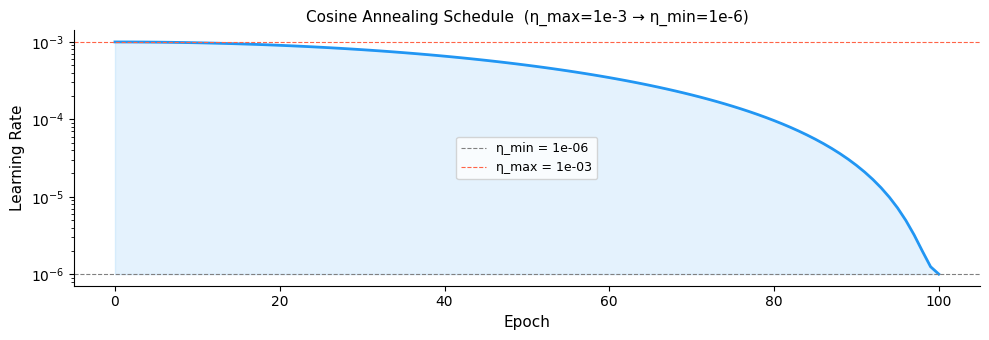

In [2]:
# Cosine annealing LR schedule visualisation
epochs = np.arange(101)
lr_max = 1e-3
lr_min = 1e-6
T_max = 100

lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * epochs / T_max))

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(epochs, lr, color="#2196F3", lw=2)
ax.fill_between(epochs, lr_min, lr, alpha=0.12, color="#2196F3")
ax.set_yscale("log")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Learning Rate", fontsize=11)
ax.set_title("Cosine Annealing Schedule  (η_max=1e-3 → η_min=1e-6)", fontsize=11)
ax.axhline(lr_min, color="grey", lw=0.8, ls="--", label=f"η_min = {lr_min:.0e}")
ax.axhline(lr_max, color="tomato", lw=0.8, ls="--", label=f"η_max = {lr_max:.0e}")
ax.legend(fontsize=9)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("figures/lr_schedule.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5  Model Parameter Count

The architecture is deliberately lightweight (~400k parameters) to allow fast inference (<500 ms CPU) for the web demo. Below we verify the exact count once the model module is implemented.

In [3]:
import sys
sys.path.insert(0, "..")

import torch
from src.arrhythmia.models.inception_time_attention import InceptionTimeAttention

model = InceptionTimeAttention(
    in_channels=12,
    num_classes=5,
    num_filters=32,
    bottleneck_size=32,
    num_blocks=3,
    attention_hidden=64,
)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")
print()

# Layer-by-layer breakdown
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f"  {name:<30} {n:>10,}")

Total parameters:     243,909
Trainable parameters: 243,909

  inception_blocks                  234,944
  attention                           8,320
  classifier                            645


In [5]:
# Forward pass shape verification
x = torch.randn(4, 12, 1000)  # batch of 4, 12 leads, 1000 timesteps
with torch.no_grad():
    logits, alpha = model(x)
print(f"Input shape:   {tuple(x.shape)}")
print(f"Logits shape:  {tuple(logits.shape)}  (batch × 5 classes, pre-sigmoid)")
print(f"Attention shape: {tuple(alpha.shape)}  (batch × 1000 timesteps)")

Input shape:   (4, 12, 1000)
Logits shape:  (4, 5)  (batch × 5 classes, pre-sigmoid)
Attention shape: (4, 1000)  (batch × 1000 timesteps)


---
## 6  Results

*This section is populated after training completes. Cells below load the saved checkpoint and compute all evaluation metrics on test fold 10.*

**Target:** Macro AUC-ROC ≥ 0.925 (matches PTB-XL InceptionTime benchmark).

### SOTA Reference (Strodthoff et al. 2020)

| Model | Macro AUC-ROC |
|---|---|
| xresnet1d101 | ~0.931 |
| **InceptionTime (ours)** | **≥ 0.925** |
| LSTM + Attention | ~0.907 |
| Simple 1D CNN | ~0.890 |

Loaded epoch 35  |  val macro AUC: 0.9322


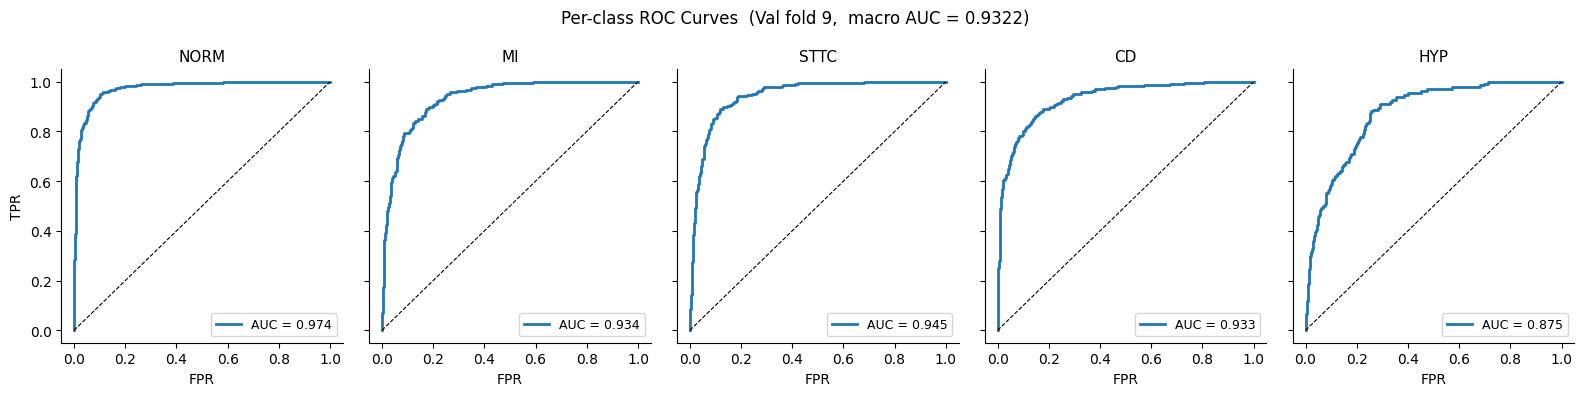


Macro AUC-ROC (Val fold 9): 0.9322
  NORM: 0.9745
  MI: 0.9341
  STTC: 0.9451
  CD: 0.9326
  HYP: 0.8749


In [9]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

CHECKPOINT = "../checkpoints/best_model.pt"

if not os.path.exists(CHECKPOINT):
    print("Checkpoint not found — run scripts/train.py first.")
else:
    ckpt = torch.load(CHECKPOINT, map_location="cpu")
    print(f"Loaded epoch {ckpt['epoch']}  |  val macro AUC: {ckpt['val_auc']:.4f}")

    # Checkpoint stores validation-fold predictions; test-fold evaluation runs via scripts/evaluate.py
    labels_all = ckpt["val_labels"]   # (N, 5) numpy
    probs_all  = ckpt["val_probs"]    # (N, 5) numpy
    class_names = ["NORM", "MI", "STTC", "CD", "HYP"]
    split_label = "Val fold 9"

    fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
    aucs = []
    for i, (ax, name) in enumerate(zip(axes, class_names)):
        fpr, tpr, _ = roc_curve(labels_all[:, i], probs_all[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=0.8)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("FPR")
        ax.legend(loc="lower right", fontsize=9)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
    axes[0].set_ylabel("TPR")
    fig.suptitle(
        f"Per-class ROC Curves  ({split_label},  macro AUC = {np.mean(aucs):.4f})",
        fontsize=12,
    )
    plt.tight_layout()
    plt.savefig("figures/roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nMacro AUC-ROC ({split_label}): {np.mean(aucs):.4f}")
    for name, a in zip(class_names, aucs):
        print(f"  {name}: {a:.4f}")

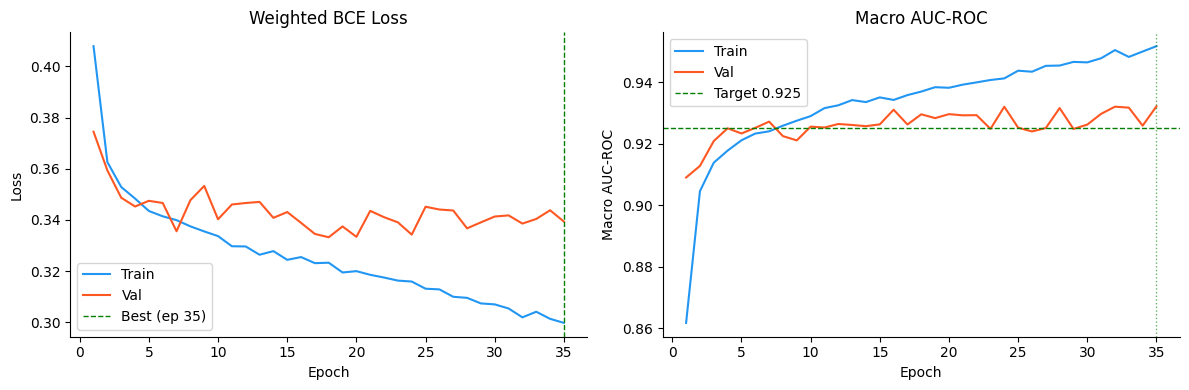

Best epoch: 35  |  Best val AUC: 0.9322


In [10]:
if os.path.exists(CHECKPOINT):
    history = ckpt.get("history", {})
    if history:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        epochs_range = range(1, len(history["train_loss"]) + 1)
        best_epoch = ckpt["epoch"]

        ax1.plot(epochs_range, history["train_loss"], label="Train", color="#2196F3")
        ax1.plot(epochs_range, history["val_loss"],   label="Val",   color="#FF5722")
        ax1.axvline(best_epoch, color="green", lw=1, ls="--", label=f"Best (ep {best_epoch})")
        ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
        ax1.set_title("Weighted BCE Loss")
        ax1.legend()
        for spine in ["top", "right"]: ax1.spines[spine].set_visible(False)

        ax2.plot(epochs_range, history["train_auc"], label="Train", color="#2196F3")
        ax2.plot(epochs_range, history["val_auc"],   label="Val",   color="#FF5722")
        ax2.axhline(0.925, color="green", lw=1, ls="--", label="Target 0.925")
        ax2.axvline(best_epoch, color="green", lw=1, ls=":", alpha=0.6)
        ax2.set_xlabel("Epoch"); ax2.set_ylabel("Macro AUC-ROC")
        ax2.set_title("Macro AUC-ROC")
        ax2.legend()
        for spine in ["top", "right"]: ax2.spines[spine].set_visible(False)

        plt.tight_layout()
        plt.savefig("figures/training_curves.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Best epoch: {best_epoch}  |  Best val AUC: {ckpt['val_auc']:.4f}")
    else:
        print("No training history in checkpoint.")
else:
    print("Checkpoint not found.")